In [51]:
import torch
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import global_mean_pool
from torch_geometric.utils import to_dense_adj
import torch.nn as nn
import sys
import importlib.util
import os


In [52]:
# 1. Bypass the broken __init__.py and load models directly from the file
path_to_models = os.path.abspath(os.path.join('..', 'src', 'models.py'))
spec = importlib.util.spec_from_file_location("models_direct", path_to_models)
models_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(models_module)

GAT_Layer = models_module.GATLayer
GATv2_Layer = models_module.GATv2Layer

print("✅ layers loaded successfully!")

✅ layers loaded successfully!


In [63]:
# 1. Define the path relative to the repo root
# This looks up one level from 'notebooks' to find the 'data' directory
root_dir = os.path.join(os.getcwd(), '..', 'data', 'QM9')

# 2. Load the dataset
# PyG will check this folder; if it's empty, it will download there
full_dataset = QM9(root=root_dir)

# 3. CPU-Friendly Subset (First 5,000 molecules)
# We use a fixed seed for the split to ensure GAT and GATv2 see the same data
torch.manual_seed(42)
subset_indices = torch.randperm(len(full_dataset))[:1000]
dataset = full_dataset[subset_indices]

# 4. Train/Test Split (80/20)
# Instead of slicing the first 4k, we shuffle to get a representative mix of molecules
num_train = 800
train_set = dataset[:num_train]
test_set = dataset[num_train:]

# 5. DataLoaders
# Batch size 32 is a "sweet spot" for CPU cache performance
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

print(f"Data location: {os.path.abspath(root_dir)}")
print(f"Training samples: {len(train_set)} | Test samples: {len(test_set)}")

Data location: /Users/anushkavijay/Code/research/gat-wrecked/data/QM9
Training samples: 800 | Test samples: 200


In [64]:
class QM9_Model(nn.Module):
    def __init__(self, layer_class, in_channels, hidden_channels, out_channels, nheads=4, dropout=0.2, alpha=0.2):
        super().__init__()
        self.nheads = nheads
        
        # 1. Multi-head First Layer
        self.conv1_heads = nn.ModuleList([
            layer_class(in_channels, hidden_channels, dropout=dropout, alpha=alpha, concat=True)
            for _ in range(nheads)
        ])
        
        # 2. Second Layer (takes concatenated output of conv1)
        # We'll use a single head here for the transition to the pooling layer
        self.conv2 = layer_class(hidden_channels * nheads, hidden_channels * nheads, 
                                 dropout=dropout, alpha=alpha, concat=False)
        
        # 3. Final regression head
        self.lin = nn.Linear(hidden_channels * nheads, out_channels)

    def forward(self, x, adj, batch):
        # Apply multi-head first layer
        x = torch.cat([att(x, adj) for att in self.conv1_heads], dim=1)
        x = F.elu(x)
        
        # Apply second layer
        x = self.conv2(x, adj)
        x = F.elu(x)
        
        # Global Pooling (Average all atoms in the molecule)
        x = global_mean_pool(x, batch) 
        
        return self.lin(x)

In [65]:
def train(model, loader, optimizer, device):
    model.train()
    total_error = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        # 1. Convert sparse edge_index to dense adjacency matrix
        # This creates a [1, N, N] tensor where N is the total nodes in the batch
        adj = to_dense_adj(data.edge_index).squeeze(0)
        
        # 2. Pass data.batch so the model knows which atoms belong to which molecule
        out = model(data.x, adj, data.batch)
        
        loss = F.l1_loss(out, data.y[:, 0:1])
        loss.backward()
        optimizer.step()
        total_error += loss.item() * data.num_graphs
    return total_error / len(loader.dataset)

In [66]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_error = 0
    for data in loader:
        data = data.to(device)
        adj = to_dense_adj(data.edge_index).squeeze(0)
        out = model(data.x, adj, data.batch)
        error = F.l1_loss(out, data.y[:, 0:1])
        total_error += error.item() * data.num_graphs
    return total_error / len(loader.dataset)

In [67]:
device = torch.device('cpu')
epochs = 50 
hidden_dim = 64
nheads = 4

# Initialize models
# Assuming GAT_Model and GATv2_Model are imported from your src/models.py
model_gat = QM9_Model(GAT_Layer, in_channels=11, hidden_channels=32, out_channels=1, nheads=4)
model_v2  = QM9_Model(GATv2_Layer, in_channels=11, hidden_channels=32, out_channels=1, nheads=4)

optimizer_gat = optim.Adam(model_gat.parameters(), lr=0.001)
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=0.001)

gat_history = []
v2_history = []

for epoch in range(1, epochs + 1):
    train_mae_gat = train(model_gat, train_loader, optimizer_gat, device)
    test_mae_gat = evaluate(model_gat, test_loader, device)
    gat_history.append(test_mae_gat)
    
    train_mae_v2 = train(model_v2, train_loader, optimizer_v2, device)
    test_mae_v2 = evaluate(model_v2, test_loader, device)
    v2_history.append(test_mae_v2)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | GAT MAE: {test_mae_gat:.4f} | GATv2 MAE: {test_mae_v2:.4f}")

Epoch 005 | GAT MAE: 0.9466 | GATv2 MAE: 0.9943
Epoch 010 | GAT MAE: 0.9897 | GATv2 MAE: 1.0188
Epoch 015 | GAT MAE: 0.9417 | GATv2 MAE: 0.9304
Epoch 020 | GAT MAE: 0.9254 | GATv2 MAE: 0.9265
Epoch 025 | GAT MAE: 0.9336 | GATv2 MAE: 0.9161
Epoch 030 | GAT MAE: 0.9563 | GATv2 MAE: 0.9745
Epoch 035 | GAT MAE: 0.9374 | GATv2 MAE: 0.9145
Epoch 040 | GAT MAE: 0.9164 | GATv2 MAE: 0.8983
Epoch 045 | GAT MAE: 0.9147 | GATv2 MAE: 0.8868
Epoch 050 | GAT MAE: 0.9165 | GATv2 MAE: 0.9185


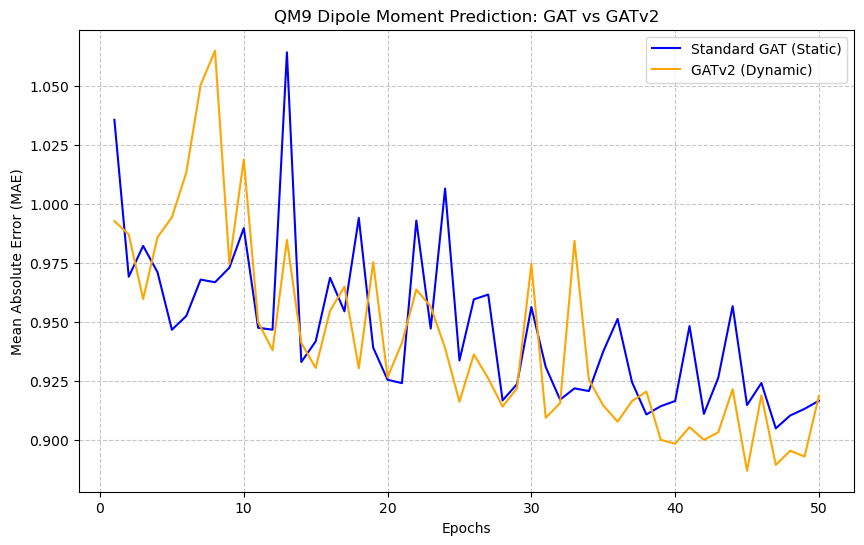

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), gat_history, label='Standard GAT (Static)', color='blue')
plt.plot(range(1, epochs + 1), v2_history, label='GATv2 (Dynamic)', color='orange')

plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('QM9 Dipole Moment Prediction: GAT vs GATv2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()